In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
POINTS = np.array([(10, 10), (20, 10)]) # Tuple of (bins, pulls) points

In [4]:
process_times = np.array([])
fill_spectra_all_times = np.array([])
fill_spectra_phys_times = np.array([])
fill_spectra_nuis_times = np.array([])
chi2_times = np.array([])
chi2_with_grad_times = np.array([])

for bins, pulls in POINTS:
    with open(f'./scaling_outputs/scale_{bins}bins_{pulls}pulls.txt', 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'fillspectra_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                fill_spectra_all_times = np.append(fill_spectra_all_times, time)
            elif 'fillspectra_vary_phys' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                fill_spectra_phys_times = np.append(fill_spectra_phys_times, time)
            elif 'fillspectra_vary_nuis' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                fill_spectra_nuis_times = np.append(fill_spectra_nuis_times, time)
            elif 'metric_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                chi2_times = np.append(chi2_times, time)
            elif 'metric_grad_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                chi2_with_grad_times = np.append(chi2_with_grad_times, time)

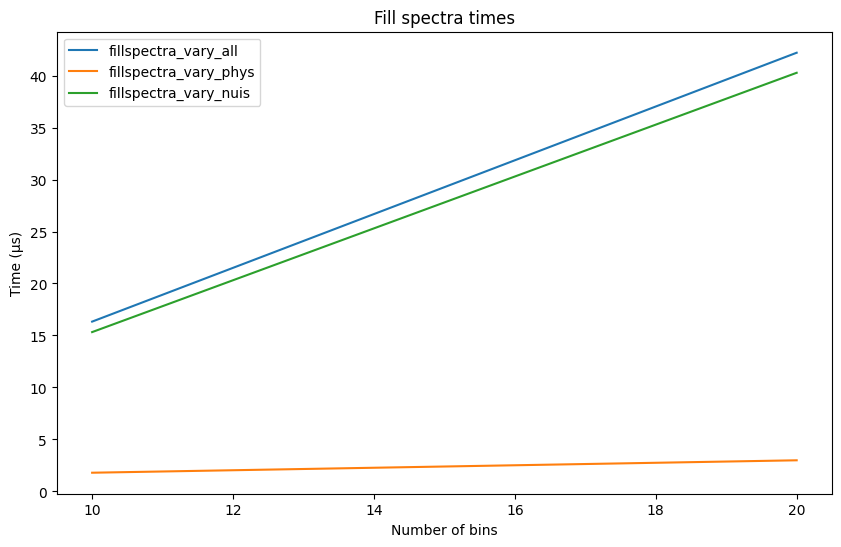

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(POINTS[:, 0], fill_spectra_all_times, label='fillspectra_vary_all')
plt.plot(POINTS[:, 0], fill_spectra_phys_times, label='fillspectra_vary_phys')
plt.plot(POINTS[:, 0], fill_spectra_nuis_times, label='fillspectra_vary_nuis')
plt.legend()
plt.xlabel('Number of bins')
plt.ylabel('Time (μs)')
plt.title('Fill spectra times')
plt.show()

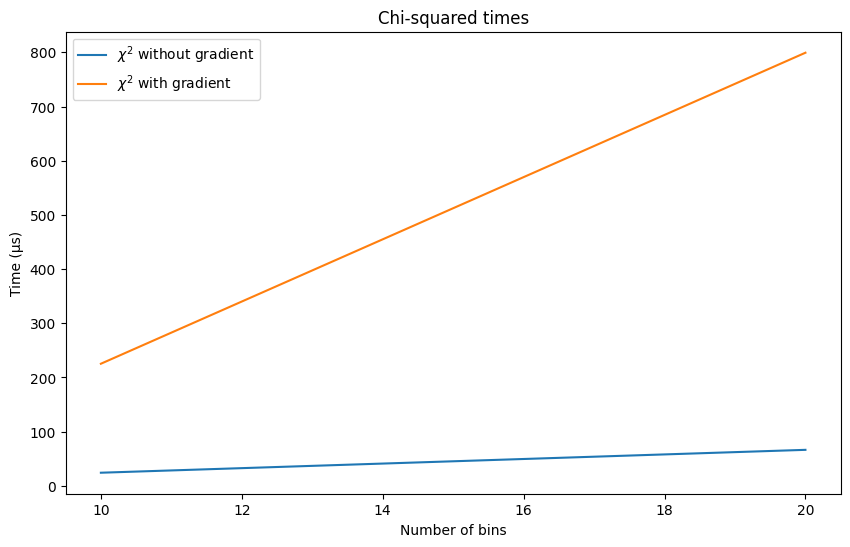

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(POINTS[:, 0], chi2_times, label='$\\chi^2$ without gradient')
plt.plot(POINTS[:, 0], chi2_with_grad_times, label='$\\chi^2$ with gradient')
plt.legend()
plt.xlabel('Number of bins')
plt.ylabel('Time (μs)')
plt.title('Chi-squared times')
plt.show()